In [1]:
JSON_FILE_PATH = "./json/front/A1-A3.json"

In [2]:
from src.json_pose import PoseData3D
import src.kpt_special_data as kpt_special_data
import src.plot_painter as plot_painter
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [3]:
data = PoseData3D(JSON_FILE_PATH)
json_pth = Path(JSON_FILE_PATH)

In [ ]:
### 視角參數
# elev, azim, roll = 20, 30, 0  # 預設
# elev, azim, roll = 30, 180, 0  # 右側
# elev, azim, roll = 30, 90, 0  # 正面

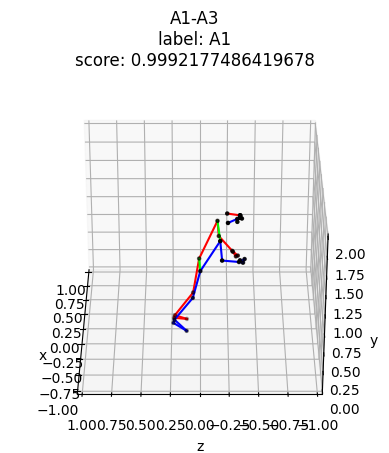

In [11]:
### 參數設定
frame_idx = 0  # 影像幀索引值
# 顯示資料範圍
data_range_x = [-1, 1]  # x 軸
data_range_y = [-1, 1]  # y 軸
data_range_z = [0, 2]  # z 軸
# 設定視角
elev, azim, roll = 20, 30, 0
# 圖表是否為 3D
is_3d = True
# 顏色
c_left = "#f00"  # 左邊
c_center = "#0f0"  # 右邊
c_right = "#00f"  # 中間
c_dot = "#000"  # 關鍵點
# 繪製關鍵點大小
dot_size = 5

assert data.get_number_of_poses(frame_idx) > 0  # 判斷影像幀是否有姿勢

### 取得所需資料
p_left, p_center, p_right = data.get_pos_connection_list(
    frame_idx, 0, kpt_special_data.blazepose_connection, True
)
p_kpt = data.get_pos_list(frame_idx, 0, True)
label = data.get_lhc_label(frame_idx, 0)
score = data.get_kpt_score(frame_idx, 0)
title_name = f"{json_pth.stem}\nlabel: {label}\nscore: {score}"

### 轉換成 numpy 格式
p_left = np.array(p_left)
p_center = np.array(p_center)
p_right = np.array(p_right)
p_kpt = np.array(p_kpt)
# 取得 y 軸要加的數值
plus_to_y = p_kpt[:, 1].max()
# 反轉 y 軸數值，並加上要加的數值(腳底為0)
p_left[:, :, 1] = p_left[:, :, 1] * -1 + plus_to_y
p_center[:, :, 1] = p_center[:, :, 1] * -1 + plus_to_y
p_right[:, :, 1] = p_right[:, :, 1] * -1 + plus_to_y
p_kpt[:, 1] = p_kpt[:, 1] * -1 + plus_to_y

### 圖表設置
ax = plt.subplot(projection="3d") if is_3d else plt.subplot()
ax.set_title(title_name)
ax.view_init(elev, azim, roll)  # 設置視角
# 設置參數範圍
plot_painter.set_data_range(data_range_x, data_range_y, data_range_z, ax)

### 繪製表格
plot_painter.draw_lines(p_left, is_3d, c_left, ax)
plot_painter.draw_lines(p_center, is_3d, c_center, ax)
plot_painter.draw_lines(p_right, is_3d, c_right, ax)
plot_painter.draw_dots(p_kpt, c_dot, dot_size, c_dot, ax)

plt.show()